LienShape extraction with PyPAS 

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

from pyspectrum import germanium_fwhm,TimeChannelParser, Spectrum
from pyPAS.pas_db import PASdb, PAScdb
from pyPAS.coincidence_events_filter import PasCoincidenceFilter

from pathlib import Path
import os
from uncertainties import nominal_value
from uncertainties.unumpy import nominal_values, std_devs

definitions

In [2]:
energy_calib_poly_det_1 = np.poly1d([0.0408976444, 0.0822321508])
energy_calib_poly_det_2 = np.poly1d([0.0418921521, 0.0653720462])

energy_resolution_det_1 = 1.05 
energy_resolution_det_2 = 1.08 

estimated_FWHM_det_1 = lambda energy: germanium_fwhm(energy, 0, energy_resolution_det_1/511**0.5, 0)
estimated_FWHM_det_2 = lambda energy: germanium_fwhm(energy, 0, energy_resolution_det_2/511**0.5, 0)

# Define regions for lineshpape parameters
energy_domain_s = [510.1, 511.9]         # Region B (S parameter)
energy_domain_w_l = [506, 509.3]         # Region A or C (left)
energy_domain_w_r = [512.7, 516]         # Region A or C (right)
total_energy_domain = [506, 516]

# Cu 500

In [3]:
def get_calibrated_spectrum(file_path, approximated_calibration, estimated_FWHM):
    # load
    data = pd.read_csv(file_path, skiprows=5, sep=' ', names=['time', 'channel', 'flag'], usecols=range(3))
    time = (data['time'].max()-data['time'].min())*1e-8
    spectrum = TimeChannelParser.to_spectrum(data, approximated_calibration, estimated_FWHM)
    
    # first calibration correction due to bug that happend
    calibration_correction = nominal_value(spectrum.energy_calibration(spectrum.argmax()).item())- 511
    new_energy_calib = np.poly1d([approximated_calibration[1], approximated_calibration[0] - calibration_correction])
    spectrum.calibrate_energy(new_energy_calib)
    db = PASdb.from_spectrum(spectrum)
    db.centralize_annihilation_peak()
    return db

## files

In [4]:
data_dir_1 = Path('../libs/cu_sample_500/detector_0/')
data_dir_2 = Path('../libs/cu_sample_500/detector_1/')

files_in_dir_1 = os.listdir(data_dir_1)
files_in_dir_2 = os.listdir(data_dir_2)

# now we take the data for the two detector
db_spectra_files_1 = []
db_spectra_files_2 = []

energies_1 = []
energies_2 = []

for file in files_in_dir_1:
    try:
        energies_1.append(float(file[:file.find('e')])/1000)
        db_spectra_files_1.append(data_dir_1 / file)
    except:
        pass

for file in files_in_dir_2:
    try:
        energies_2.append(float(file[:file.find('e')])/1000)
        db_spectra_files_2.append(data_dir_2 / file)
    except:
        pass

### creating DB obejects

In [5]:
db_1 = []
db_2 = []

s_1 = []
s_2 = []

w_1 = []
w_2 = []

energies = []

for energy in energies_1:
    
    file_1 = db_spectra_files_1[energies_1.index(energy)]
    file_2 = db_spectra_files_2[energies_2.index(energy)]

    db_1 = get_calibrated_spectrum(file_1, energy_calib_poly_det_1, estimated_FWHM_det_1)

    db_2 = get_calibrated_spectrum(file_2, energy_calib_poly_det_2, estimated_FWHM_det_2)

    s_1.append(db_1.s_parameter_calculation(total_energy_domain, energy_domain_s))
    w_1.append(db_1.w_parameter_calculation(total_energy_domain, energy_domain_w_l, energy_domain_w_r))
        
    s_2.append(db_2.s_parameter_calculation(total_energy_domain, energy_domain_s))
    w_2.append(db_2.w_parameter_calculation(total_energy_domain, energy_domain_w_l, energy_domain_w_r))
    
    energies.append(energy)
        
s_1 = xr.DataArray(np.array(s_1), coords={'energy':energies})
s_2 = xr.DataArray(np.array(s_2), coords={'energy':energies})
w_1 = xr.DataArray(np.array(w_1), coords={'energy':energies})
w_2 = xr.DataArray(np.array(w_2), coords={'energy':energies})

In [12]:
s = (s_1+s_2)/2
w = (w_1+w_2)/2

# Plots

Text(0, 0.5, 'W Parameter')

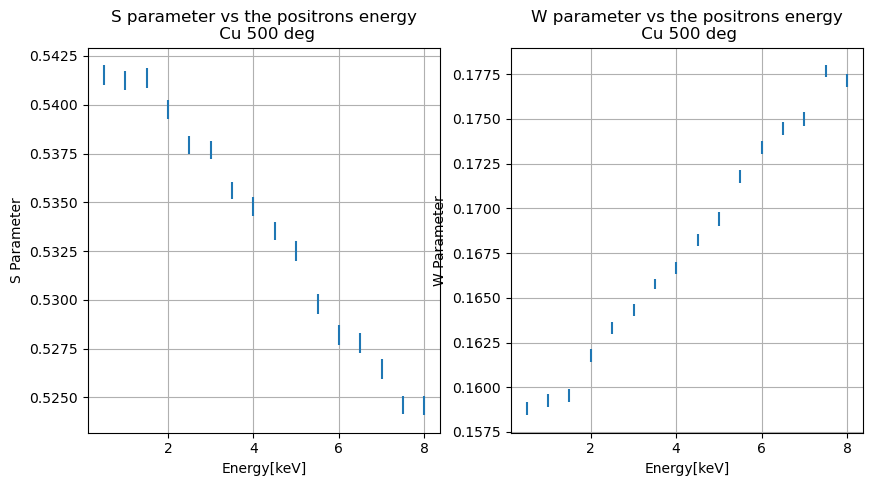

In [13]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)  # 1 row, 3 columns, 1st subplot

plt.errorbar(x=energies, y=nominal_values(s), yerr=std_devs(s), ls='')

plt.title('S parameter vs the positrons energy\n Cu 500 deg')
plt.grid(True)
plt.xlabel('Energy[keV]')
plt.ylabel('S Parameter')

plt.subplot(1, 2, 2)  # 1 row, 3 columns, 1st subplot

plt.errorbar(x=energies, y=nominal_values(w), yerr=std_devs(w), ls='')
plt.title('W parameter vs the positrons energy\n Cu 500 deg')
plt.grid(True)
plt.xlabel('Energy[keV]')
plt.ylabel('W Parameter')


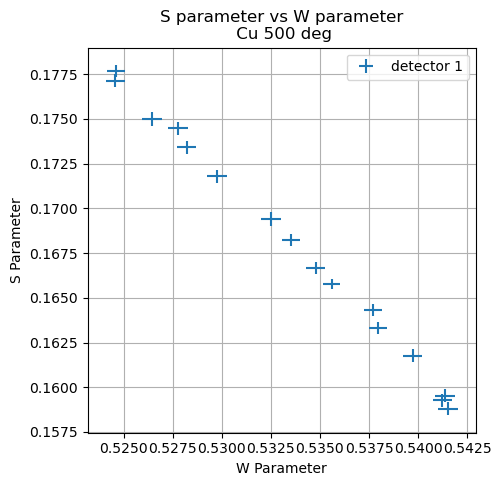

In [14]:
plt.figure(figsize=(5, 5))

plt.errorbar(x=nominal_values(s), y=nominal_values(w), yerr=std_devs(w), xerr=std_devs(s), ls='')

plt.title('S parameter vs W parameter\n Cu 500 deg')
plt.grid(True)
plt.xlabel('W Parameter')
plt.ylabel('S Parameter')
plt.legend(['detector 1', 'detector 2'])

In [9]:
nominal = xr.DataArray(nominal_values(s.values), coords=s.coords, dims=s.dims)
stddev = xr.DataArray(std_devs(s.values), coords=s.coords, dims=s.dims)

# Step 2: Save to a file
dataset = xr.Dataset({
    'nominal': nominal,
    'uncertainty': stddev
})

dataset.to_netcdf('../libs/cu_sample_500/lineshape_new.nc')